In [344]:
%load_ext autoreload
%reload_ext autoreload
%autoreload 2
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from neural_net import NeuralNet
import mushrooms as shroom
import graphics
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [345]:
mnist = fetch_openml('mnist_784', as_frame=False)
X, y = mnist.data, mnist.target
X = np.array(X)

In [346]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, stratify=y, random_state=42)

In [347]:
y = np.astype(y, int)
y_processed = np.zeros((len(y), 10))
for i, y_p in enumerate(y_processed):
    y_p[y[i]] =1

y = y_processed 
X = X/255
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [373]:
from prev_neural_net import pNeuralNet

neural_net = pNeuralNet((28**2, 256, 10), learning_rate=0.001, random_state=42)
neural_net.layers[0].activation_method="ReLu"
neural_net.layers[0].weights = neural_net.layers[0].initialize("He")

neural_net.layers[-1].activation_method="softmax"
epochs = 10
losses, y_pred = neural_net.train(X_train,
                                  y_train,
                                  epochs,
                                  batch_size = 32,
                                  validate=(X_test, y_test),
                                  binary=True,
                                  lr_scheduling=True,
                                  noise_normalization=True)


EPOCH: 1    LOSS: 0.0227904    LOSS CHANGE: 0    TEST ACCURACY: 0.9534    TEST ACCURACY CHANGE 0.9534
EPOCH: 2    LOSS: 0.00930736    LOSS CHANGE: -0.01348    TEST ACCURACY: 0.9671    TEST ACCURACY CHANGE 0.01371
EPOCH: 3    LOSS: 0.00608827    LOSS CHANGE: -0.003219    TEST ACCURACY: 0.9714    TEST ACCURACY CHANGE 0.004214
EPOCH: 4    LOSS: 0.00422021    LOSS CHANGE: -0.001868    TEST ACCURACY: 0.9763    TEST ACCURACY CHANGE 0.004929
EPOCH: 5    LOSS: 0.00311356    LOSS CHANGE: -0.001107    TEST ACCURACY: 0.9773    TEST ACCURACY CHANGE 0.001
EPOCH: 6    LOSS: 0.00250002    LOSS CHANGE: -0.0006135    TEST ACCURACY: 0.9756    TEST ACCURACY CHANGE -0.001643
EPOCH: 7    LOSS: 0.00199796    LOSS CHANGE: -0.0005021    TEST ACCURACY: 0.9758    TEST ACCURACY CHANGE 0.0001429
EPOCH: 8    LOSS: 0.00150425    LOSS CHANGE: -0.0004937    TEST ACCURACY: 0.9761    TEST ACCURACY CHANGE 0.0002857
EPOCH: 9    LOSS: 0.00135532    LOSS CHANGE: -0.0001489    TEST ACCURACY: 0.9751    TEST ACCURACY CHANGE -

In [ ]:
neural_net = NeuralNet((28**2, 256, 10), learning_rate=0.001, random_state=42)
neural_net.layers[0].activation_method="ReLu"
neural_net.layers[0].weights = neural_net.layers[0].initialize("He")

neural_net.layers[-1].activation_method="softmax"
epochs = 10
losses, y_pred = neural_net.train(X_train,
                                  y_train,
                                  epochs,
                                  batch_size = 32,
                                  validate=(X_test, y_test[:100]),
                                  categorical=True,
                                  lr_scheduling=True,
                                  noise_normalization=True)

EPOCH: 1    LOSS: 0.0227904    LOSS CHANGE: 0    TEST ACCURACY: 0.9534    TEST ACCURACY CHANGE 0.9534    TIME: 9.8 s
EPOCH: 2    LOSS: 0.00930736    LOSS CHANGE: -0.01348    TEST ACCURACY: 0.9671    TEST ACCURACY CHANGE 0.01371    TIME: 9.6 s
EPOCH: 3    LOSS: 0.00608827    LOSS CHANGE: -0.003219    TEST ACCURACY: 0.9714    TEST ACCURACY CHANGE 0.004214    TIME: 11 s
EPOCH: 4    LOSS: 0.00422021    LOSS CHANGE: -0.001868    TEST ACCURACY: 0.9763    TEST ACCURACY CHANGE 0.004929    TIME: 13 s
EPOCH: 5    LOSS: 0.00311356    LOSS CHANGE: -0.001107    TEST ACCURACY: 0.9773    TEST ACCURACY CHANGE 0.001    TIME: 9.9 s
EPOCH: 6    LOSS: 0.00250002    LOSS CHANGE: -0.0006135    TEST ACCURACY: 0.9756    TEST ACCURACY CHANGE -0.001643    TIME: 14 s
EPOCH: 7    LOSS: 0.00199796    LOSS CHANGE: -0.0005021    TEST ACCURACY: 0.9758    TEST ACCURACY CHANGE 0.0001429    TIME: 10 s
EPOCH: 8    LOSS: 0.00150425    LOSS CHANGE: -0.0004937    TEST ACCURACY: 0.9761    TEST ACCURACY CHANGE 0.0002857    TI

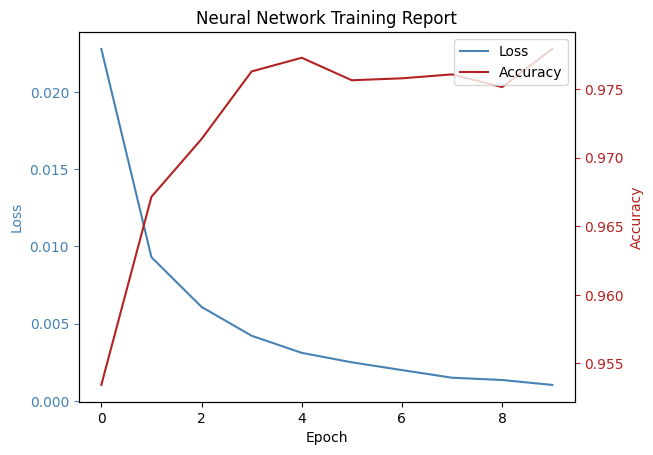

In [375]:
graphics.plot_report(neural_net)

In [376]:
neural_net.export("models/MNIST_net.h5")

Neural Network exported to models/MNIST_net.h5


In [377]:
from sklearn.metrics import accuracy_score

y_pred = neural_net.predict(X_test)
y_pred_accuracy = np.where(y_pred > 0.5, 1, 0)
print(f"Accuracy: {accuracy_score(y_pred_accuracy, y_test)}")

Accuracy: 0.9779285714285715


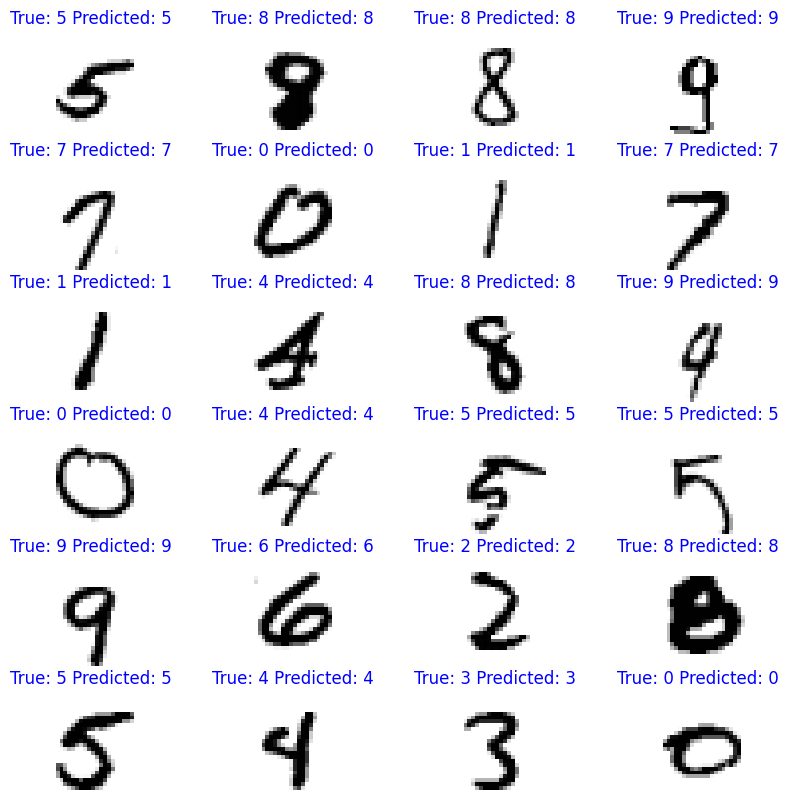

In [378]:
def display_num(ax, X, i, true, pred):
    X_image = np.swapaxes(np.array(np.split(X, 28, axis=1)), 1, 0)
    ax.imshow(X_image[i], cmap="gray_r")
    ax.set_title(f'True: {true} Predicted: {pred}', c="blue" if true == pred else "red")
    ax.axis('off') # Hide axis ticks

rows = 6
cols = 4

fig, axs = plt.subplots(rows, cols, figsize=(10, 10))

for i in range(rows*cols):
    current_row = i // cols
    current_col = i % cols
    
    # Select the correct subplot axis
    ax = axs[current_row, current_col]
    display_num(ax, X_test, i+100, y_test.argmax(axis=1)[i+100], y_pred.argmax(axis=1)[i+100])
plt.show()

Num wrong predictions: 303 out of 14000


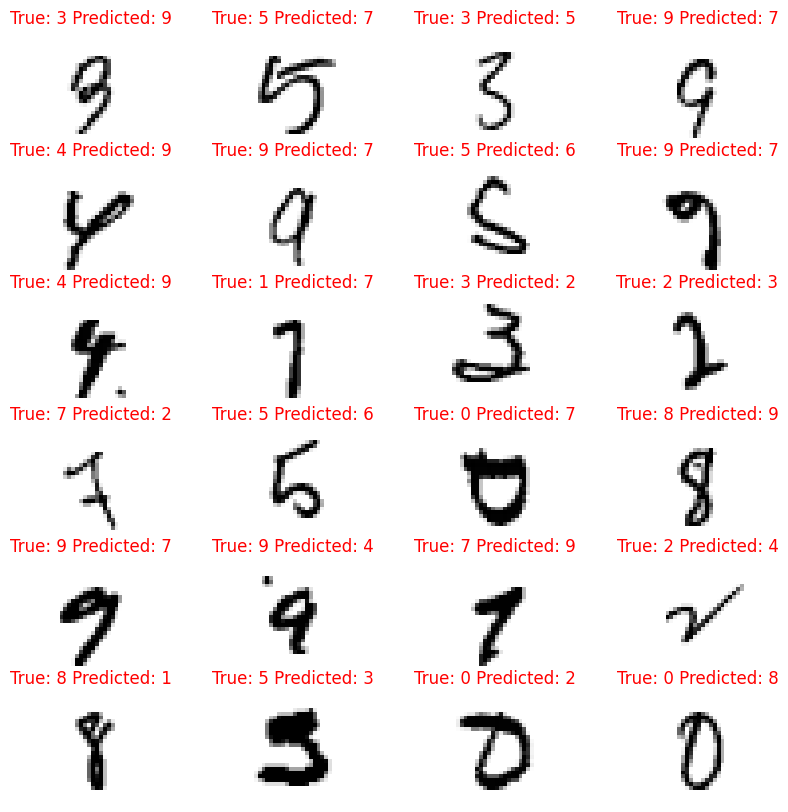

In [379]:

wrong_indices = y_test.argmax(axis=1) != y_pred.argmax(axis=1)
y_test_wrong = y_test.argmax(axis=1)[wrong_indices]
y_pred_wrong = y_pred.argmax(axis=1)[wrong_indices]
X_wrong = X_test[wrong_indices]

fig, axs = plt.subplots(rows, cols, figsize=(10, 10))

for i in range(rows*cols):
    current_row = i // cols
    current_col = i % cols
    
    # Select the correct subplot axis
    ax = axs[current_row, current_col]
    display_num(ax, X_wrong, i, y_test_wrong[i], y_pred_wrong[i])
print(f"Num wrong predictions: {len(X_wrong)} out of {len(X_test)}")
plt.show()

Pred: [[5.46587802e-14 1.31100178e-17 6.65518065e-04 9.99334403e-01
  1.70668350e-26 7.90394277e-08 4.15628394e-12 1.28330399e-13
  1.10019422e-14 7.78193667e-21]]


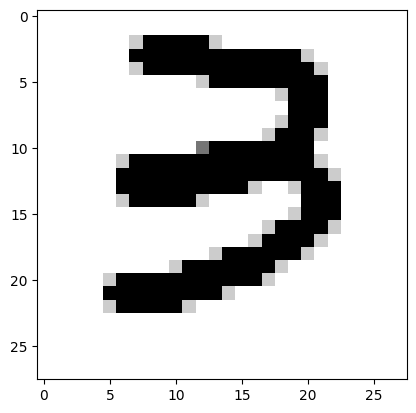

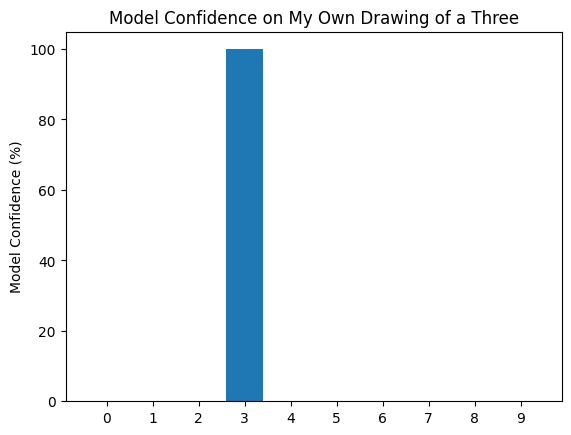

In [ ]:
# can it predict my own writing?

my_three = plt.imread('three.png')[:, :28, 0]
X_my = np.array([(1 - my_three).flatten()])
y_pred_my = neural_net.predict(X_my)
print(f"Pred: {y_pred_my}")
plt.imshow(my_three, cmap="gray")
plt.show()
plt.title("Model Confidence on My Own Drawing of a Three")
plt.ylabel("Model Confidence (%)")
plt.bar(np.arange(10), 100*y_pred_my.flatten())
plt.xticks(np.arange(10))
plt.show()